<a href="https://colab.research.google.com/github/j-see17/Python-Coding/blob/main/Another_copy_of_BUMK744_Conjoint_Class_I_iPhone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BUMK744 — Conjoint Analysis I
## Why did Apple go bigger on iPhone screens?

---

**Objectives:**

1. **Load** a conjoint dataset (240 respondents × 16 iPhone profiles).
2. **Estimate** partworths via OLS — first pooled, then per respondent.
3. **Compute** attribute importance and simulate **market share**.
4. **Discover** the two target segments with **k-means clustering** (iPhone X/XS vs SE/XR).
5. **Stress-test** the model and discuss what breaks when products are described by *unstructured* data (images, text) — the bridge to today's AI-era conjoint research.

> **Pre-class checkpoint.** Before you run anything, write down your own guess for the *rank order* of attribute importance (brand, screen, price, storage, mobile-payment). We'll compare your intuition to the data in §4.

---
**How to use this notebook:** Click **Runtime → Run all** or step through cell by cell with `Shift+Enter`.

## §1. Setup

Google Colab ships with `pandas`, `numpy`, `matplotlib`, `scikit-learn`, and `statsmodels` pre-installed — nothing to install. Just run the cell below.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import itertools, random, io, csv

pd.set_option('display.float_format', lambda v: f'{v:+.3f}')
np.set_printoptions(precision=3, suppress=True)
print('All libraries loaded ✔')

All libraries loaded ✔


## §2. Load the conjoint dataset


### Study design

| Design choice | Value |
|---|---|
| **Attributes** | Brand (Samsung/Apple), Screen (4.0″/4.7″), Price (\$649/\$749), Storage (16GB/64GB), Payment (No/Yes) |
| **Profiles** | 16 (half-fraction of 2⁵, defining relation I = ABCDE, Resolution V) |
| **Respondents** | 240
| **Rating** | Continuous utility score per profile per respondent |


In [ ]:
url = 'https://raw.githubusercontent.com/XinyingHao/BUMK744/refs/heads/main/iphone-conjoint.csv'
df = pd.read_csv(url)
df.head(10)

,respondent_id,segment_true,profile_id,brand,screen,price,storage,payment,rating
0,1,A,1,0,0,0,0,1,+1.311
1,1,A,2,0,0,0,1,0,+1.875
2,1,A,3,0,0,1,0,0,+0.929
3,1,A,4,0,0,1,1,1,+1.755
4,1,A,5,0,1,0,0,0,+2.290
5,1,A,6,0,1,0,1,1,+3.409
6,1,A,7,0,1,1,0,1,+2.283
7,1,A,8,0,1,1,1,0,+2.731
8,1,A,9,1,0,0,0,0,+2.015
9,1,A,10,1,0,0,1,1,+3.004


### The 16 conjoint profiles

We have 5 binary attributes → 2⁵ = 32 possible products. But our orthogonal design uses only **16** profiles (half-fraction, defining relation I = ABCDE). This means all five main effects are estimable and un-confounded with any two-factor interactions.

In [ ]:
# The 16 unique profiles in the design
profiles = df.drop_duplicates('profile_id').sort_values('profile_id')[
    ['profile_id', 'brand', 'screen', 'price', 'storage', 'payment']
].reset_index(drop=True)
profiles

,profile_id,brand,screen,price,storage,payment
0,1,0,0,0,0,1
1,2,0,0,0,1,0
2,3,0,0,1,0,0
3,4,0,0,1,1,1
4,5,0,1,0,0,0
5,6,0,1,0,1,1
6,7,0,1,1,0,1
7,8,0,1,1,1,0
8,9,1,0,0,0,0
9,10,1,0,0,1,1


**💬 Quick check (30 sec with your neighbor).** We have 5 binary attributes, which gives 2⁵ = 32 possible products. Why do we only see **16** profiles? *(Hint: see slide 18 on orthogonal main-effects fractional factorial design.)*

## §3. Pooled OLS — the "average" iPhone buyer

Our conjoint utility model:

$$ U_{ij} = \beta_0 + \beta_1\,\text{brand}_j + \beta_2\,\text{screen}_j + \beta_3\,\text{price}_j + \beta_4\,\text{storage}_j + \beta_5\,\text{payment}_j + \varepsilon_{ij} $$

We fit this on **all 240 respondents at once** to get the "average consumer's" partworths. We'll use `statsmodels` for a regression table.

In [ ]:
features = ['brand', 'screen', 'price', 'storage', 'payment']
X = sm.add_constant(df[features])
y = df['rating']

model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 rating   R-squared:                       0.567
Model:                            OLS   Adj. R-squared:                  0.567
Method:                 Least Squares   F-statistic:                     1005.
Date:                Mon, 13 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:09:07   Log-Likelihood:                -3886.1
No. Observations:                3840   AIC:                             7784.
Df Residuals:                    3834   BIC:                             7822.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.2429      0.026     47.198      0.000       1.191       1.295
brand          0.7518      0.022     34.966      0.000       0.710       0.794
screen         0.8452      0.022     39.310      0.000       0.803       0.887
price         -0.6380      0.022    -29.674      0.000      -0.680      -0.596
storage        0.7553      0.022     35.128      0.000       0.713       0.797
payment        0.2547      0.022     11.848      0.000       0.213       0.297
==============================================================================
Omnibus:                      536.540   Durbin-Watson:                   0.540
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              782.597
Skew:                          -1.078   Prob(JB):                    1.15e-170
Kurtosis:                       3.489   Cond. No.                         4.79
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### 📝 Stop and read the regression table

Look at the coefficients:
- Which are **negative**? Which are the **largest**?
- Does anything look weird from a **marketer's perspective**?

You should see a *negative* coefficient on `price` (good — consumers dislike paying more) and a *positive* screen coefficient. But the pooled screen coefficient is **suspiciously muted**. That is our first hint that a single "average consumer" is hiding something…

## §4. Attribute importance and market-share simulation

**Attribute importance** = range of partworths for that attribute ÷ sum of ranges across all attributes.

This corresponds to the "Stages 8: Insights 1 & 2" step from the lecture slides.

In [ ]:
# Attribute importance (for binary attributes, range = |coefficient|)
ranges = model.params[features].abs()
importance = (ranges / ranges.sum()).round(3) * 100
importance.name = 'importance_%'
importance.sort_values(ascending=False).to_frame()

,importance_%
screen,+26.000
storage,+23.300
brand,+23.200
price,+19.700
payment,+7.900


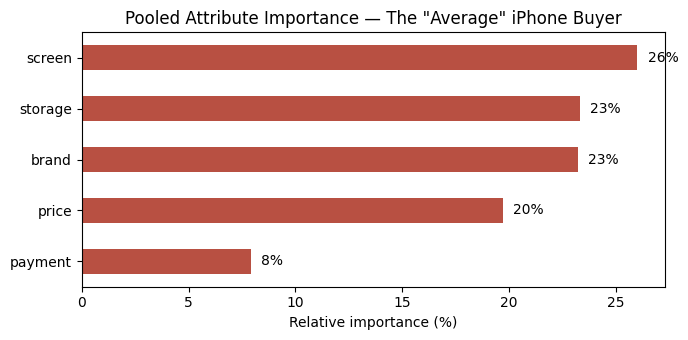

In [ ]:
fig, ax = plt.subplots(figsize=(7, 3.5))
importance.sort_values().plot.barh(ax=ax, color='#B85042')
ax.set_xlabel('Relative importance (%)')
ax.set_title('Pooled Attribute Importance — The "Average" iPhone Buyer')
for i, v in enumerate(importance.sort_values().values):
    ax.text(v + 0.5, i, f'{v:.0f}%', va='center', fontsize=10)
plt.tight_layout()
plt.show()

**Compare to your pre-class guess.** Did you rank the attributes in the same order? Most students are surprised that screen size ranks lower than brand — but remember, this is the *pooled* model. The magic happens when we look per-segment.

### Mini market-share simulator

Given partworths, we can predict how an *arbitrary* new product would perform against competitors using a **logit share-of-preference** rule:

$$\text{Share}_k = \frac{\exp(U_k)}{\sum_{m} \exp(U_m)}$$

In [ ]:
def utility(params, product):
    """Compute utility of a product given a set of partworths."""
    return (params['const']
            + params['brand']   * product['brand']
            + params['screen']  * product['screen']
            + params['price']   * product['price']
            + params['storage'] * product['storage']
            + params['payment'] * product['payment'])

def share_of_preference(params, products):
    """Logit share-of-preference for a set of competing products."""
    u = np.array([utility(params, p) for p in products])
    e = np.exp(u)
    return e / e.sum()

# Scenario: 3-product competitive landscape
lineup = [
    dict(name='Samsung 4.0" $649',   brand=0, screen=0, price=0, storage=0, payment=1),
    dict(name='Apple   4.7" $749',   brand=1, screen=1, price=1, storage=1, payment=1),
    dict(name='Apple   4.0" $649',   brand=1, screen=0, price=0, storage=0, payment=1),
]

print('=== Pooled Market Share Simulation ===')
print()
shares = share_of_preference(model.params, lineup)
for p, s in zip(lineup, shares):
    print(f"  {p['name']:25s}  share = {s:6.1%}")

=== Pooled Market Share Simulation ===

  Samsung 4.0" $649          share =  11.5%
  Apple   4.7" $749          share =  64.0%
  Apple   4.0" $649          share =  24.5%


**💬 Try it yourself.** Change one attribute on the "Apple 4.0″ \$649" product (e.g., flip `screen=0` to `screen=1`) and re-run the cell. Which single attribute change gives Apple the biggest share lift?

## §5. One model per respondent — individual-level partworths

The pooled model assumes everyone has the same taste. **Reality: consumers differ.** Let's estimate a separate OLS regression for each of the 240 respondents.

*(Note: commercial tools like Sawtooth use Hierarchical Bayes for this step, which adds Bayesian shrinkage. We keep it simple with OLS here — the intuition is identical.)*

In [ ]:
def fit_one(sub):
    """Fit OLS for a single respondent's 16 ratings."""
    X_i = sm.add_constant(sub[features])
    y_i = sub['rating']
    return sm.OLS(y_i, X_i).fit().params

indiv = df.groupby('respondent_id').apply(fit_one).reset_index()
print(f'Individual partworths computed for {len(indiv)} respondents')
indiv.head()

Individual partworths computed for 240 respondents


/tmp/ipykernel_8598/3261527934.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  indiv = df.groupby('respondent_id').apply(fit_one).reset_index()


,respondent_id,const,brand,screen,price,storage,payment
0,1,+1.096,+0.830,+1.319,-0.388,+0.790,+0.235
1,2,+1.363,+0.665,+1.206,-0.429,+0.757,+0.387
2,3,+1.043,+0.606,+1.271,-0.380,+0.823,+0.388
3,4,+1.181,+0.705,+1.394,-0.310,+0.823,+0.352
4,5,+1.188,+0.829,-0.069,-1.322,+0.964,+0.209


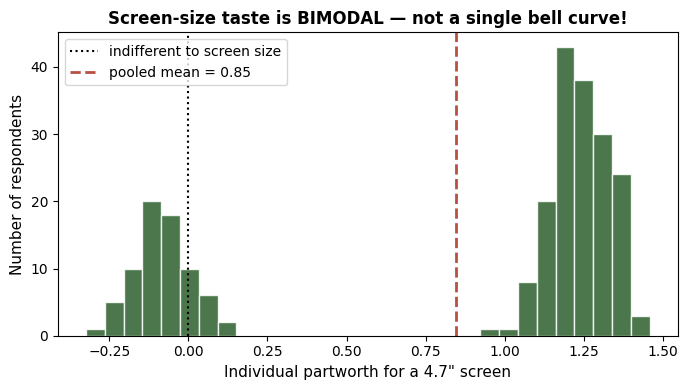

In [ ]:
# The key reveal: distribution of the SCREEN partworth across respondents
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(indiv['screen'], bins=30, color='#2C5F2D', edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', ls=':', lw=1.5, label='indifferent to screen size')
ax.axvline(indiv['screen'].mean(), color='#B85042', ls='--', lw=2,
           label=f'pooled mean = {indiv["screen"].mean():.2f}')
ax.set_xlabel('Individual partworth for a 4.7" screen', fontsize=11)
ax.set_ylabel('Number of respondents', fontsize=11)
ax.set_title('Screen-size taste is BIMODAL — not a single bell curve!', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

### The two humps tell the story

See the **bimodal distribution**? There are clearly two groups:
- A large group that **loves** bigger screens (partworth >> 0)
- A smaller group that is **indifferent or slightly negative** on screen size

The pooled model *averages* these two humps into one muted coefficient — and **loses the signal entirely.** This is exactly why Apple *eventually* shipped both the iPhone X/XS (big) **and** the iPhone SE (compact).

## §6. Discovering the two segments with k-means clustering

We'll cluster the 240 respondents on their 5 partworths (excluding the intercept). Because partworths live on different scales, we **standardize** before clustering.

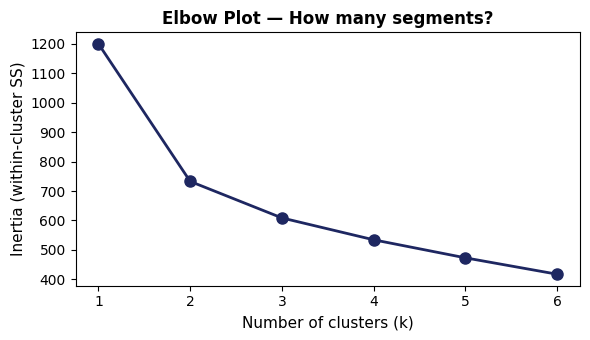

The "elbow" at k=2 suggests two distinct segments.


In [ ]:
# Step 1: Elbow plot to choose k
feat_cols = features  # brand, screen, price, storage, payment
X_pw = indiv[feat_cols].values
X_pw_z = StandardScaler().fit_transform(X_pw)

inertias = []
for k in range(1, 7):
    km = KMeans(n_clusters=k, n_init=10, random_state=7).fit(X_pw_z)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(range(1, 7), inertias, 'o-', color='#1E2761', lw=2, markersize=8)
ax.set_xlabel('Number of clusters (k)', fontsize=11)
ax.set_ylabel('Inertia (within-cluster SS)', fontsize=11)
ax.set_title('Elbow Plot — How many segments?', fontsize=12, fontweight='bold')
ax.set_xticks(range(1, 7))
plt.tight_layout()
plt.show()
print('The "elbow" at k=2 suggests two distinct segments.')

In [ ]:
# Step 2: Fit k=2 and recover segment partworths
km = KMeans(n_clusters=2, n_init=10, random_state=7).fit(X_pw_z)
indiv['cluster'] = km.labels_

# Re-estimate partworths WITHIN each cluster for interpretability
segment_partworths = (
    df.merge(indiv[['respondent_id', 'cluster']], on='respondent_id')
      .groupby('cluster')
      .apply(fit_one)
)

print('=== Segment-level partworths ===')
print()
segment_partworths.round(3)

=== Segment-level partworths ===



/tmp/ipykernel_8598/1656865608.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(fit_one)


,const,brand,screen,price,storage,payment
cluster,,,,,,
0,+1.243,+0.751,+1.242,-0.353,+0.758,+0.255
1,+1.242,+0.754,-0.080,-1.303,+0.749,+0.254


### Compare to slide 31 (Target Market 1 vs Target Market 2)

You should see numbers very close to:

| Segment | intercept | brand | screen | price | storage | payment |
|---|---|---|---|---|---|---|
| **Big-screen cluster** | +1.25 | +0.75 | **+1.25** | −0.35 | +0.75 | +0.25 |
| **Compact cluster** | +1.25 | +0.75 | **−0.10** | **−1.30** | +0.75 | +0.25 |

**Key insight:** The big-screen cluster has a screen partworth of **+1.25** (they *love* bigger screens) while the compact cluster's screen partworth is only **−0.10** (they don't care about screen size) but their price sensitivity is **4× stronger** (−1.30 vs −0.35).

> The "big-screen" cluster rushed to the iPhone X/XS. The "compact" cluster held out for the SE/XR.

In [ ]:
# Step 3: How well did unsupervised clustering recover the true segments?
from sklearn.metrics import adjusted_rand_score

truth = (df.drop_duplicates('respondent_id')
           .set_index('respondent_id')['segment_true'])
truth_num = (truth == 'A').astype(int)
pred = indiv.set_index('respondent_id')['cluster']

# Labels might be flipped, so check both orientations
acc = max((pred == truth_num).mean(), (pred == 1 - truth_num).mean())
ari = adjusted_rand_score(truth_num, pred)

print(f'Segment recovery accuracy:  {acc:.1%}')
print(f'Adjusted Rand Index:        {ari:.3f}')
print()
print('Cluster sizes:')
print(indiv['cluster'].value_counts().sort_index().to_string())

Segment recovery accuracy:  100.0%
Adjusted Rand Index:        1.000

Cluster sizes:
cluster
0    168
1     72


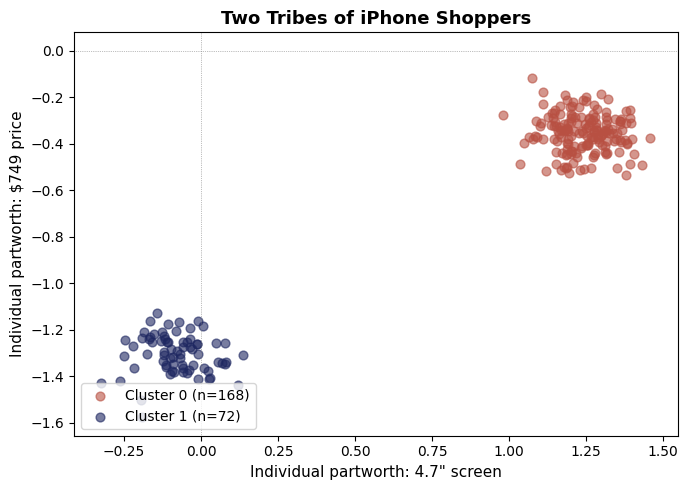

In [ ]:
# Step 4: Visualize the two tribes in the screen × price partworth plane
colors = ['#B85042', '#1E2761']
labels_map = {0: 'Cluster 0', 1: 'Cluster 1'}

fig, ax = plt.subplots(figsize=(7, 5))
for c in (0, 1):
    sub = indiv[indiv['cluster'] == c]
    ax.scatter(sub['screen'], sub['price'],
               color=colors[c], alpha=0.6, s=40,
               label=f'Cluster {c} (n={len(sub)})')

ax.axhline(0, color='grey', lw=0.5, ls=':')
ax.axvline(0, color='grey', lw=0.5, ls=':')
ax.set_xlabel('Individual partworth: 4.7" screen', fontsize=11)
ax.set_ylabel('Individual partworth: $749 price', fontsize=11)
ax.set_title('Two Tribes of iPhone Shoppers', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='lower left')
plt.tight_layout()
plt.show()

## §7. Market-share simulator — now by segment

This is the **"ah-ha" moment**: the pooled model and the segmented model give very different product recommendations. Let's re-run the same 3-product scenario, but compute share *within each segment*.

In [ ]:
def share_by_segment(params_table, products):
    """Compute market share for each segment separately."""
    out = {}
    for cluster_id, params in params_table.iterrows():
        shares = share_of_preference(params, products)
        out[f'Cluster {cluster_id}'] = [f'{s:.1%}' for s in shares]
    result = pd.DataFrame(out, index=[p['name'] for p in products])
    return result

print('=== Market Share by Segment ===')
print()
share_by_segment(segment_partworths, lineup)

=== Market Share by Segment ===



,Cluster 0,Cluster 1
"Samsung 4.0"" $649",7.1%,23.5%
"Apple 4.7"" $749",77.9%,26.5%
"Apple 4.0"" $649",15.0%,50.0%


### What changed?

In the pooled model, the three products had relatively balanced shares. But **by segment**, the picture is dramatic:
- The **big-screen cluster** overwhelmingly prefers the Apple 4.7″ — they'll pay the premium for size.
- The **compact/price cluster** gravitates toward the cheap Apple 4.0″ — they care about price, not screen.

**This is why segmentation matters.** A single "average" model would lead Apple to ship one middle-of-the-road phone. The segmented model says: ship *two* phones for *two* audiences.

**💬 Classroom debate.** You're Tim Cook in 2016. Given the partworths above, do you ship **one big iPhone** (X/XS) or **two iPhones** (X/XS *and* a compact SE)? What data would change your mind?

## §8. Interactive playground — design your own product

Use this cell to test **any** iPhone configuration against competitors. Edit the `my_lineup` list and re-run.

In [ ]:
# ┌──────────────────────────────────────────────────────────────┐
# │  EDIT THIS SECTION — design your own competitive scenario!  │
# └──────────────────────────────────────────────────────────────┘

my_lineup = [
    # Each product: brand (0=Samsung, 1=Apple), screen (0=4.0", 1=4.7"),
    #               price (0=$649, 1=$749), storage (0=16GB, 1=64GB),
    #               payment (0=No, 1=Yes)

    dict(name='iPhone Pro 4.7"',     brand=1, screen=1, price=1, storage=1, payment=1),
    dict(name='iPhone XR 4.0"',      brand=1, screen=0, price=0, storage=0, payment=1),
    dict(name='Samsung Galaxy 4.7"', brand=0, screen=1, price=0, storage=1, payment=1),
]

# ── Pooled share ──
print('=== POOLED (one average consumer) ===')
pooled_shares = share_of_preference(model.params, my_lineup)
for p, s in zip(my_lineup, pooled_shares):
    print(f"  {p['name']:28s}  share = {s:6.1%}")

# ── Per-segment share ──
print()
print('=== BY SEGMENT ===')
for cluster_id, params in segment_partworths.iterrows():
    print(f"\n  Cluster {cluster_id}:")
    seg_shares = share_of_preference(params, my_lineup)
    for p, s in zip(my_lineup, seg_shares):
        print(f"    {p['name']:28s}  share = {s:6.1%}")

=== POOLED (one average consumer) ===
  iPhone Pro 4.7"               share =  44.0%
  iPhone XR 4.0"                share =  16.8%
  Samsung Galaxy 4.7"           share =  39.2%

=== BY SEGMENT ===

  Cluster 0:
    iPhone Pro 4.7"               share =  53.6%
    iPhone XR 4.0"                share =  10.3%
    Samsung Galaxy 4.7"           share =  36.0%

  Cluster 1:
    iPhone Pro 4.7"               share =  21.7%
    iPhone XR 4.0"                share =  40.8%
    Samsung Galaxy 4.7"           share =  37.5%


## §9. Preview — conjoint in the age of AI

Everything we just did assumed **structured attributes**: brand, screen size, price, storage, mobile payment. But what if the product is a Netflix thumbnail, an Airbnb listing photo, or a piece of ad copy? There's no clean list of attribute levels.

### Two research frontiers to watch

**1. Unstructured-data conjoint** (Dew 2024, *Management Science*)

Uses image/text *embeddings* + Bayesian optimization so each survey question adapts to what the respondent has already said. No manual attribute coding needed. Think: "Which of these two sneaker photos do you prefer?" — and the model learns your taste in design space.

**2. Digital twins / LLM respondents** (Brand, Israeli & Ngwe 2023; Horton 2023)

Prompt a large language model as if it were a specific consumer demographic and collect its "preferences." Cheap and fast — but the Stanford "Funhouse Mirrors" mega-study (2025) found digital twins correlate with humans at only r = 0.20. Open question: when are they good enough?

### When does traditional conjoint break?

Apple makes decisions every year where traditional conjoint **cannot** work:
- **Camera quality** — computational photography creates a holistic *feel* that can't be decomposed into named levels
- **Design language** — flat edges vs rounded edges, titanium vs stainless steel
- **Dynamic Island** — an entirely new interaction paradigm that didn't exist in consumers' vocabulary
- **Ecosystem effects** — iMessage, AirDrop, Apple Watch pairing

These are exactly the settings where Dew (2024)'s embedding-based approach shines.

## §10. Self-check questions

Test your understanding before next class:

1. Why does the **pooled** screen partworth look so small compared to the per-segment ones?
2. The price partworth for the compact segment is −1.30. If you raise the price by one level (\$649 → \$749), how much rating does that segment lose?
3. You run your own conjoint and the elbow plot is perfectly smooth (no elbow). What do you do?
4. Without looking at §9, describe one concrete setting where classical conjoint **cannot** work and AI-era methods might.
5. A colleague says "just run the pooled model — individual-level estimation is overkill." Using today's results, construct a one-sentence rebuttal.